# Fundamentos de aprendizaje por refuerzo

Queremos estudiar situaciones en las que una decision tomada hoy afecta lo que ocurrira en los siguientes pasos. Por ejemplo, un robot que debe encontrar una salida, un videojuego en el que un personaje debe sumar puntos o un repartidor que debe escoger la mejor ruta. En todos estos casos no basta con acertar una sola vez: necesitamos una estrategia que produzca buenos resultados a lo largo del tiempo.

En este tutorial establecemos nociones fundamentales sobre el aprendizaje por refuerzo mediante ejemplos pequenos, faciles de seguir y completamente implementados en Python.

## Requisitos

Para desarrollar este tutorial necesitaras:
* Declarar variables, ciclos y funciones en Python.
* Manipular arreglos de `numpy` y tablas sencillas con `pandas`.
* Crear visualizaciones basicas con `matplotlib`.

## Objetivos

Al final de este tutorial podras:

**1.** Identificar los elementos principales de un problema de aprendizaje por refuerzo.<br>
**2.** Entender la logica general del algoritmo Q-learning.<br>
**3.** Construir agentes sencillos que aprenden a tomar decisiones a partir de recompensas.

## 1. Aprendizaje por refuerzo

El aprendizaje por refuerzo es una rama del *machine learning* en la que un agente aprende por ensayo y error. El agente interactua con un entorno, toma acciones y recibe recompensas. Con el tiempo, aprende cuales decisiones le convienen mas.

A diferencia del aprendizaje supervisado, aqui no entregamos una respuesta correcta para cada observacion. En cambio, el agente debe descubrir una buena estrategia a partir de las consecuencias de sus acciones.

### 1.1. Elementos basicos

Los conceptos mas importantes son:

* **Agente:** quien toma decisiones.
* **Entorno:** el sistema con el que interactua el agente.
* **Estado:** la situacion actual del agente.
* **Accion:** una decision posible dentro del entorno.
* **Recompensa:** el puntaje que recibe el agente despues de actuar.
* **Episodio:** una secuencia completa de interacciones desde el inicio hasta el final.
* **Politica:** la regla que usa el agente para escoger acciones.

### 1.2. Idea general de Q-learning

Uno de los algoritmos mas conocidos de aprendizaje por refuerzo es **Q-learning**. La idea es construir una tabla, llamada tabla Q, que indique que tan conveniente es tomar una accion en un estado determinado.

En cada paso actualizamos la tabla con una regla como la siguiente:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]$$

donde:
* $s$ es el estado actual.
* $a$ es la accion tomada.
* $r$ es la recompensa recibida.
* $s'$ es el siguiente estado.
* $\alpha$ controla que tan rapido aprende el agente.
* $\gamma$ indica que tanta importancia damos a las recompensas futuras.

### 1.3. Pasos tipicos para construir un agente

**1. Definir el entorno:** establecer estados, acciones y recompensas.

**2. Inicializar la tabla Q:** comenzar con valores neutros, por ejemplo ceros.

**3. Explorar:** permitir que el agente pruebe acciones distintas para aprender.

**4. Actualizar:** despues de cada accion, ajustar la tabla Q con la recompensa observada.

**5. Repetir muchos episodios:** el aprendizaje mejora al practicar varias veces.

**6. Extraer una politica:** elegir, en cada estado, la accion con mejor valor Q.

## 2. Ejemplo 1: un agente que aprende a llegar a una meta

En este primer ejemplo construiremos un entorno muy simple. El agente esta ubicado en una linea con cinco posiciones numeradas de 0 a 4. Empieza en la posicion 0 y quiere llegar a la posicion 4.

Las acciones posibles son movernos a la izquierda o a la derecha. Cada paso cuesta `-1` punto para incentivar rutas cortas, y llegar a la meta entrega `+10` puntos.

Empecemos importando las librerias que vamos a utilizar.

* `numpy` nos ayudara a crear y actualizar la tabla Q.
* `pandas` nos permitira mostrar tablas de forma clara.
* `matplotlib` servira para visualizar la evolucion del aprendizaje.

Tambien fijamos una semilla aleatoria con `default_rng(7)` para que el ejemplo sea reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(7)

Representemos el entorno en una tabla para visualizarlo mejor.

En este caso cada fila corresponde a un **estado** posible del agente. La posicion `0` sera el punto de inicio y la posicion `4` sera la meta.

In [2]:
posiciones = pd.DataFrame({
    'estado': [0, 1, 2, 3, 4],
    'descripcion': ['inicio', 'camino', 'camino', 'camino', 'meta']
})

posiciones

,estado,descripcion
0,0,inicio
1,1,camino
2,2,camino
3,3,camino
4,4,meta


Ahora definimos las reglas del entorno.

La funcion `paso_linea(estado, accion)` representa la dinamica del problema. Cada vez que el agente toma una decision, esta funcion devuelve tres elementos:

* `siguiente_estado`: la nueva posicion del agente.
* `recompensa`: el puntaje que recibe por esa accion.
* `terminado`: un valor logico que indica si el episodio ya termino.

Observa que moverse hacia la meta tiene premio solo al final, mientras que cada paso intermedio tiene una penalizacion de `-1`. Esto hace que el agente prefiera rutas cortas.

In [3]:
acciones = {0: 'izquierda', 1: 'derecha'}
estado_final = 4

def paso_linea(estado, accion):
    if estado == estado_final:
        return estado, 0, True

    if accion == 0:
        siguiente_estado = max(0, estado - 1)
    else:
        siguiente_estado = min(estado_final, estado + 1)

    recompensa = 10 if siguiente_estado == estado_final else -1
    terminado = siguiente_estado == estado_final
    return siguiente_estado, recompensa, terminado

paso_linea(0, 1)

(1, -1, False)

Entrenaremos un agente con Q-learning. Este es el bloque mas importante del ejemplo.

Primero definimos cuatro hiperparametros:

* `alpha = 0.2`: controla que tan rapido se actualiza la tabla Q.
* `gamma = 0.9`: da peso a las recompensas futuras.
* `epsilon = 0.30`: probabilidad de explorar acciones al azar.
* `episodios = 250`: numero de veces que el agente practicara el recorrido.

Luego inicializamos `Q_linea`, una matriz de 5 estados por 2 acciones. Cada fila representa un estado y cada columna una accion posible.

Dentro del ciclo principal ocurren cuatro pasos:

* El agente empieza en el estado `0`.
* Decide entre explorar o usar la mejor accion conocida.
* Ejecuta la accion, observa la recompensa y calcula el mejor valor futuro posible.
* Actualiza la tabla Q con la regla de Q-learning.

Al final de cada episodio guardamos la recompensa total y reducimos un poco `epsilon`, de modo que el agente explore mucho al comienzo y confie mas en lo aprendido al final.

In [4]:
alpha = 0.2
gamma = 0.9
epsilon = 0.30
episodios = 250

Q_linea = np.zeros((5, 2))
recompensas = []
pasos_por_episodio = []

for episodio in range(episodios):
    estado = 0
    recompensa_total = 0

    for paso in range(20):
        if rng.random() < epsilon:
            accion = int(rng.integers(0, 2))
        else:
            accion = int(np.argmax(Q_linea[estado]))

        siguiente_estado, recompensa, terminado = paso_linea(estado, accion)
        mejor_valor_futuro = np.max(Q_linea[siguiente_estado])
        Q_linea[estado, accion] = Q_linea[estado, accion] + alpha * (
            recompensa + gamma * mejor_valor_futuro - Q_linea[estado, accion]
        )

        estado = siguiente_estado
        recompensa_total += recompensa

        if terminado:
            pasos_por_episodio.append(paso + 1)
            break
    else:
        pasos_por_episodio.append(20)

    recompensas.append(recompensa_total)
    epsilon = max(0.05, epsilon * 0.995)

Q_linea

array([[ 3.1180792 ,  4.58      ],
       [ 3.09859528,  6.2       ],
       [ 4.56428958,  8.        ],
       [ 6.10311432, 10.        ],
       [ 0.        ,  0.        ]])

Visualicemos si el agente mejora con la practica.

En la siguiente celda construimos una tabla con el historial del entrenamiento y calculamos promedios moviles de 20 episodios. Esto suaviza las fluctuaciones y permite ver mejor la tendencia general.

Si el agente esta aprendiendo, esperamos observar:

* recompensas promedio mas altas con el tiempo;
* menos pasos para llegar a la meta.

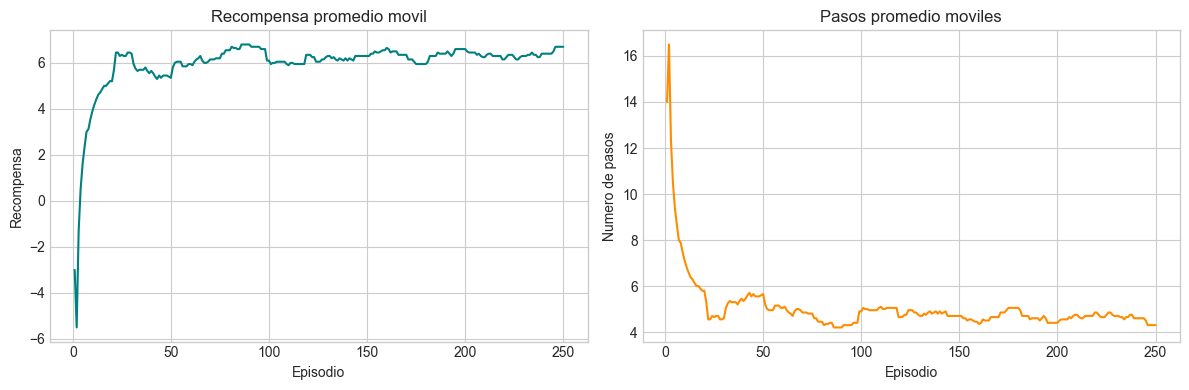

In [5]:
historial_linea = pd.DataFrame({
    'episodio': np.arange(1, episodios + 1),
    'recompensa_total': recompensas,
    'pasos': pasos_por_episodio
})
historial_linea['promedio_recompensa'] = historial_linea['recompensa_total'].rolling(20, min_periods=1).mean()
historial_linea['promedio_pasos'] = historial_linea['pasos'].rolling(20, min_periods=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(historial_linea['episodio'], historial_linea['promedio_recompensa'], color='teal')
axes[0].set_title('Recompensa promedio movil')
axes[0].set_xlabel('Episodio')
axes[0].set_ylabel('Recompensa')

axes[1].plot(historial_linea['episodio'], historial_linea['promedio_pasos'], color='darkorange')
axes[1].set_title('Pasos promedio moviles')
axes[1].set_xlabel('Episodio')
axes[1].set_ylabel('Numero de pasos')

plt.tight_layout()
plt.show()

Revisemos la tabla Q aprendida por el agente.

Cada fila corresponde a un estado y cada columna a una accion. Un valor Q alto significa que, segun la experiencia del agente, esa accion tiende a conducir a mejores resultados desde ese estado.

In [6]:
tabla_q_linea = pd.DataFrame(
    Q_linea,
    columns=['izquierda', 'derecha']
)
tabla_q_linea.index.name = 'estado'
tabla_q_linea

,izquierda,derecha
estado,,
0,3.118079,4.58
1,3.098595,6.20
2,4.564290,8.00
3,6.103114,10.00
4,0.000000,0.00


A partir de la tabla Q podemos extraer la politica aprendida.

La **politica** es simplemente la regla de decision final del agente: en cada estado elegimos la accion con el mayor valor Q.

In [7]:
politica_linea = pd.DataFrame({
    'estado': np.arange(5),
    'mejor_accion': [acciones[int(np.argmax(Q_linea[estado]))] for estado in range(5)]
})

politica_linea

,estado,mejor_accion
0,0,derecha
1,1,derecha
2,2,derecha
3,3,derecha
4,4,izquierda


Finalmente, probemos al agente siguiendo solo su politica aprendida.

En esta simulacion ya no forzamos exploracion aleatoria. El objetivo es verificar si el agente realmente aprendio una secuencia razonable de decisiones para alcanzar la meta.

In [8]:
estado = 0
trayectoria = [estado]
registro = []

for turno in range(10):
    accion = int(np.argmax(Q_linea[estado]))
    siguiente_estado, recompensa, terminado = paso_linea(estado, accion)
    registro.append({
        'turno': turno + 1,
        'estado_actual': estado,
        'accion': acciones[accion],
        'siguiente_estado': siguiente_estado,
        'recompensa': recompensa
    })
    trayectoria.append(siguiente_estado)
    estado = siguiente_estado
    if terminado:
        break

pd.DataFrame(registro)

,turno,estado_actual,accion,siguiente_estado,recompensa
0,1,0,derecha,1,-1
1,2,1,derecha,2,-1
2,3,2,derecha,3,-1
3,4,3,derecha,4,10


En este punto el agente ya aprendio que moverse a la derecha repetidamente es la forma mas conveniente de llegar a la meta. Este ejemplo es pequeno, pero muestra la idea central del aprendizaje por refuerzo.

## 3. Ejemplo 2: un robot repartidor en una cuadricula

Ahora construiremos un ejemplo un poco mas rico. Imaginemos un robot repartidor que debe moverse en una cuadricula de 3 x 3. El robot inicia en la esquina superior izquierda y quiere llegar al cliente en la esquina inferior derecha.

Habra una casilla bloqueada en el centro. Si el robot intenta pasar por ahi o salir de la cuadricula, recibira una penalizacion mayor y permanecera en la misma posicion.

Este detalle hace el problema mas interesante, porque ahora el agente no solo debe llegar a la meta, sino tambien evitar movimientos poco convenientes.

In [9]:
acciones_grid = {
    0: 'arriba',
    1: 'abajo',
    2: 'izquierda',
    3: 'derecha'
}

movimientos = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1)
}

filas, columnas = 3, 3
inicio = (0, 0)
obstaculo = (1, 1)
meta = (2, 2)

def posicion_a_estado(posicion):
    return posicion[0] * columnas + posicion[1]

def estado_a_posicion(estado):
    return divmod(estado, columnas)

def paso_cuadricula(estado, accion):
    fila, columna = estado_a_posicion(estado)
    delta_fila, delta_columna = movimientos[accion]
    nueva_fila = fila + delta_fila
    nueva_columna = columna + delta_columna

    posicion_valida = 0 <= nueva_fila < filas and 0 <= nueva_columna < columnas
    nueva_posicion = (nueva_fila, nueva_columna)

    if (not posicion_valida) or nueva_posicion == obstaculo:
        return estado, -3, False

    siguiente_estado = posicion_a_estado(nueva_posicion)
    if nueva_posicion == meta:
        return siguiente_estado, 15, True

    return siguiente_estado, -1, False

mapa = pd.DataFrame([
    ['inicio', 'camino', 'camino'],
    ['camino', 'bloqueado', 'camino'],
    ['camino', 'camino', 'meta']
])
mapa

,0,1,2
0,inicio,camino,camino
1,camino,bloqueado,camino
2,camino,camino,meta


Entrenemos el robot con Q-learning.

La logica general es la misma del ejemplo anterior, pero ahora el entorno es mas complejo:

* hay `9` estados posibles en la cuadricula;
* cada estado tiene `4` acciones (`arriba`, `abajo`, `izquierda`, `derecha`);
* salir de la cuadricula o chocar con el obstaculo genera una penalizacion de `-3`.

Por eso usamos mas episodios (`600`) y una exploracion inicial un poco mayor (`epsilon = 0.40`). El agente necesita practicar mas para descubrir una buena ruta.

In [10]:
alpha = 0.15
gamma = 0.95
epsilon = 0.40
episodios = 600

Q_grid = np.zeros((filas * columnas, 4))
recompensas_grid = []

for episodio in range(episodios):
    estado = posicion_a_estado(inicio)
    recompensa_total = 0

    for paso in range(30):
        if rng.random() < epsilon:
            accion = int(rng.integers(0, 4))
        else:
            accion = int(np.argmax(Q_grid[estado]))

        siguiente_estado, recompensa, terminado = paso_cuadricula(estado, accion)
        mejor_valor_futuro = np.max(Q_grid[siguiente_estado])
        Q_grid[estado, accion] = Q_grid[estado, accion] + alpha * (
            recompensa + gamma * mejor_valor_futuro - Q_grid[estado, accion]
        )

        estado = siguiente_estado
        recompensa_total += recompensa

        if terminado:
            break

    recompensas_grid.append(recompensa_total)
    epsilon = max(0.05, epsilon * 0.995)

pd.Series(recompensas_grid).tail()

595    12
596    12
597    12
598    12
599    12
dtype: int64

Vamos a resumir lo que aprendio el robot. Mostraremos el mejor valor Q en cada celda y la mejor accion sugerida por la politica.

En la visualizacion:

* el color representa que tan prometedor es cada estado;
* la flecha indica la accion recomendada;
* `X` marca el obstaculo;
* `G` marca la meta.

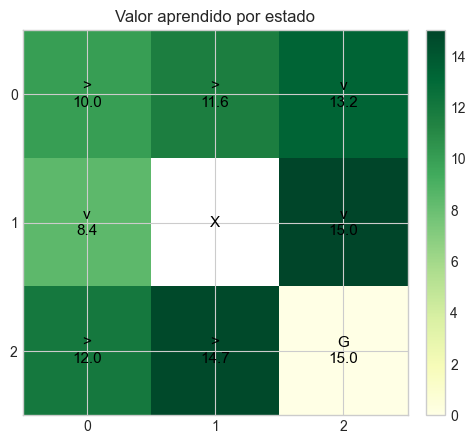

In [11]:
simbolos = {'arriba': '^', 'abajo': 'v', 'izquierda': '<', 'derecha': '>'}

mejores_valores = np.max(Q_grid, axis=1).reshape(filas, columnas)
politica_grid = np.empty((filas, columnas), dtype=object)

for estado in range(filas * columnas):
    fila, columna = estado_a_posicion(estado)
    mejor_accion = acciones_grid[int(np.argmax(Q_grid[estado]))]
    politica_grid[fila, columna] = simbolos[mejor_accion]

politica_grid[obstaculo] = 'X'
politica_grid[meta] = 'G'

valores_mostrar = mejores_valores.copy()
valores_mostrar[obstaculo] = np.nan

fig, ax = plt.subplots(figsize=(6, 5))
imagen = ax.imshow(valores_mostrar, cmap='YlGn')
ax.set_xticks(range(columnas))
ax.set_yticks(range(filas))
ax.set_title('Valor aprendido por estado')

for fila in range(filas):
    for columna in range(columnas):
        etiqueta = politica_grid[fila, columna]
        texto = f"{etiqueta}\n{mejores_valores[fila, columna]:.1f}"
        color = 'black'
        if (fila, columna) == obstaculo:
            texto = 'X'
        elif (fila, columna) == meta:
            texto = 'G\n15.0'
        ax.text(columna, fila, texto, ha='center', va='center', color=color, fontsize=11)

plt.colorbar(imagen, ax=ax, fraction=0.046, pad=0.04)
plt.show()

Probemos una ruta siguiendo solamente la politica aprendida.

La tabla resultante nos permitira revisar paso a paso que hace el robot: desde que posicion parte, que accion elige, a donde llega y que recompensa recibe.

In [12]:
estado = posicion_a_estado(inicio)
ruta = []

for turno in range(12):
    fila, columna = estado_a_posicion(estado)
    accion = int(np.argmax(Q_grid[estado]))
    siguiente_estado, recompensa, terminado = paso_cuadricula(estado, accion)
    nueva_fila, nueva_columna = estado_a_posicion(siguiente_estado)
    ruta.append({
        'turno': turno + 1,
        'posicion_actual': (fila, columna),
        'accion': acciones_grid[accion],
        'nueva_posicion': (nueva_fila, nueva_columna),
        'recompensa': recompensa
    })
    estado = siguiente_estado
    if terminado:
        break

pd.DataFrame(ruta)

,turno,posicion_actual,accion,nueva_posicion,recompensa
0,1,"(0, 0)",derecha,"(0, 1)",-1
1,2,"(0, 1)",derecha,"(0, 2)",-1
2,3,"(0, 2)",abajo,"(1, 2)",-1
3,4,"(1, 2)",abajo,"(2, 2)",15


Observa que el agente no recibio una lista de instrucciones explicitas. Solo tuvo una meta, recompensas y muchas oportunidades para practicar. A partir de eso encontro una ruta util alrededor del obstaculo.

## 4. Recomendaciones finales

El aprendizaje por refuerzo es util cuando una decision afecta las siguientes y cuando podemos describir el problema en terminos de estados, acciones y recompensas.

En este tutorial trabajamos con entornos pequenos porque alli es facil visualizar lo que esta ocurriendo. Esa es justamente una buena estrategia pedagogica: primero entender la mecanica del algoritmo en un problema simple y luego pasar a escenarios mas grandes.

En problemas pequenos, las tablas Q funcionan muy bien y son faciles de interpretar. En problemas mas grandes se suelen usar redes neuronales, simuladores y tecnicas mas avanzadas.

Como siguiente paso, puedes modificar las recompensas, el tamano del entorno, el numero de episodios o el valor de `epsilon` para observar como cambia el comportamiento del agente.